## Summative Lab: Forest Fires Prevention

**Objective:** Analyze factors contributing to wildfire size and severity, build predictive models for high-risk areas, and provide actionable recommendations for resource allocation and risk mitigation.

### Step 1: Load the Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load local CSV (extracted from the provided zip)
df = pd.read_csv('forestfires.csv')

print("Dataset shape:", df.shape)
print()
print(df.info())
print()
print(df.describe().round(2))


Dataset shape: (517, 13)

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB
None

            X       Y    FFMC     DMC      DC     ISI    temp      RH    wind  \
count  517.00  517.00  517.00  517.00  517.00  517.00  517.00  517.00  517.00   
mean     4.67    4.30   90.64  110.87  547.94    9.02   18.89   44.29    4.02   
std      2.31    

In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Target 'area' summary:")
print(df['area'].describe().round(3))
print(f"\nZero-area fires: {(df['area']==0).sum()} / {len(df)} ({(df['area']==0).mean():.1%})")


Missing values per column:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Target 'area' summary:
count     517.000
mean       12.847
std        63.656
min         0.000
25%         0.000
50%         0.520
75%         6.570
max      1090.840
Name: area, dtype: float64

Zero-area fires: 247 / 517 (47.8%)


### Step 2: Exploratory Data Analysis

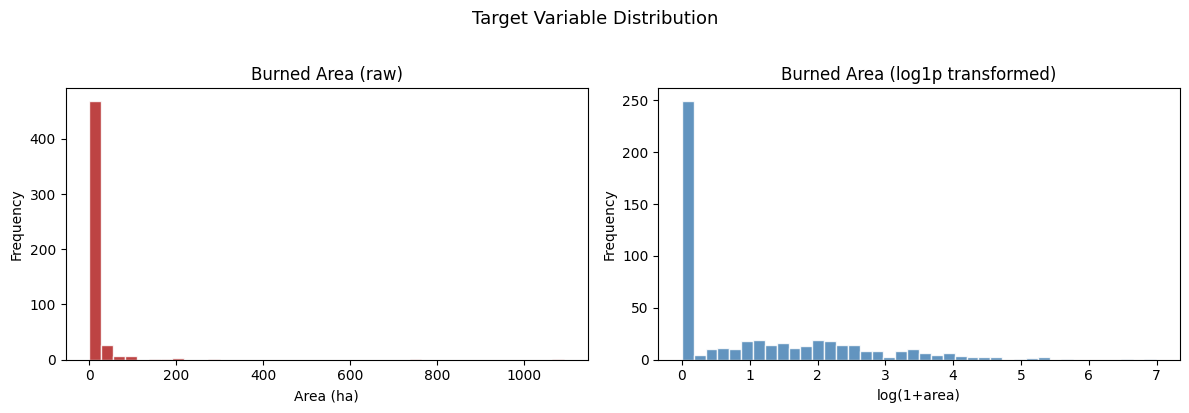

The raw target is strongly right-skewed. log1p transformation improves normality for regression.


In [3]:
# --- 2a. Target distribution & log-transform ---
df['log_area'] = np.log1p(df['area'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['area'], bins=40, color='firebrick', edgecolor='white', alpha=0.85)
axes[0].set_title('Burned Area (raw)', fontsize=12); axes[0].set_xlabel('Area (ha)')
axes[1].hist(df['log_area'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Burned Area (log1p transformed)', fontsize=12); axes[1].set_xlabel('log(1+area)')
for ax in axes: ax.set_ylabel('Frequency')
plt.suptitle('Target Variable Distribution', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print("The raw target is strongly right-skewed. log1p transformation improves normality for regression.")


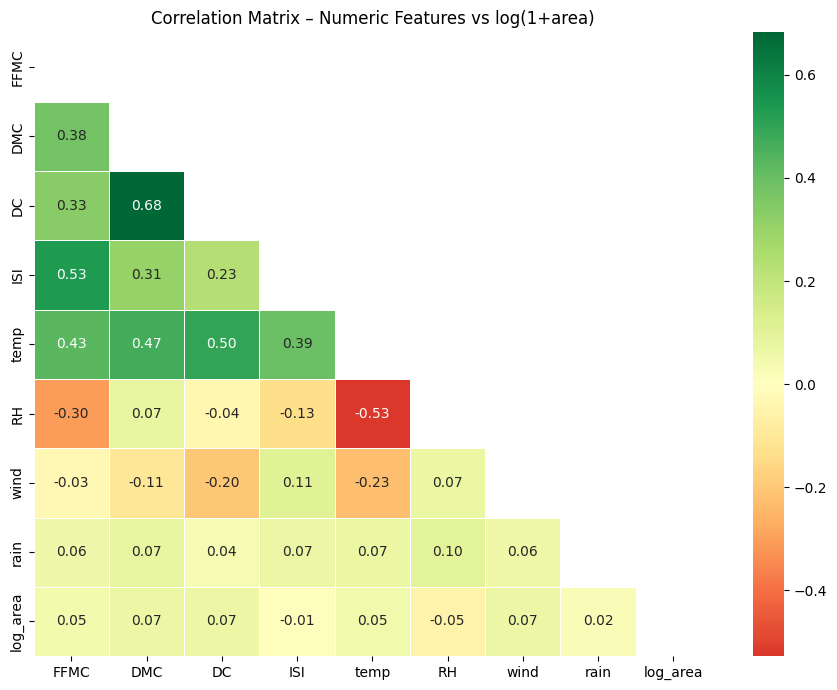

In [4]:
# --- 2b. Correlation heatmap ---
num_cols = ['FFMC','DMC','DC','ISI','temp','RH','wind','rain','log_area']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Numeric Features vs log(1+area)', fontsize=12)
plt.tight_layout(); plt.show()


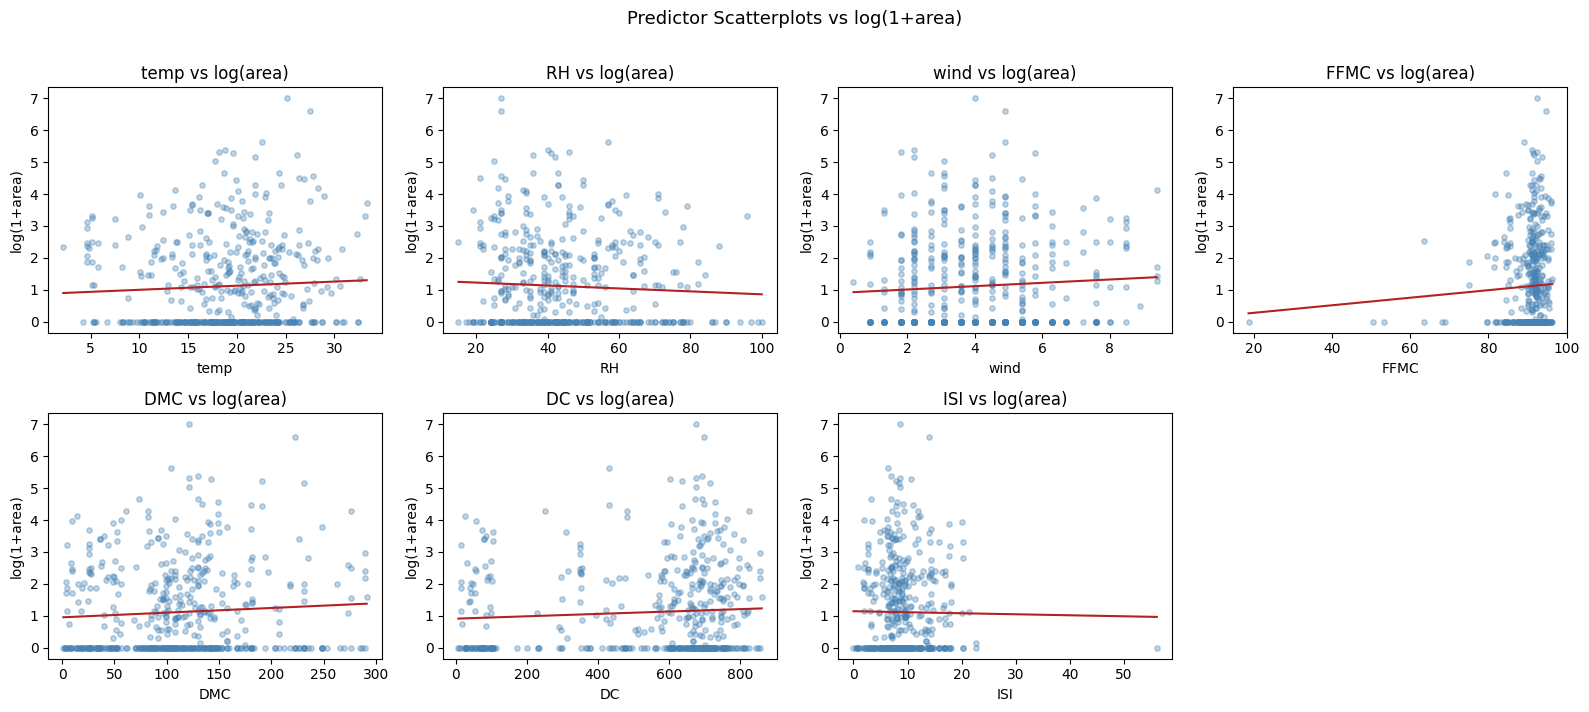

In [5]:
# --- 2c. Key predictor scatterplots ---
predictors = ['temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'ISI']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(predictors):
    axes[i].scatter(df[col], df['log_area'], alpha=0.35, s=15, color='steelblue')
    m, b = np.polyfit(df[col], df['log_area'], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(xs, m*xs+b, color='firebrick', lw=1.5)
    axes[i].set_xlabel(col); axes[i].set_ylabel('log(1+area)'); axes[i].set_title(f'{col} vs log(area)')
axes[-1].axis('off')
plt.suptitle('Predictor Scatterplots vs log(1+area)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


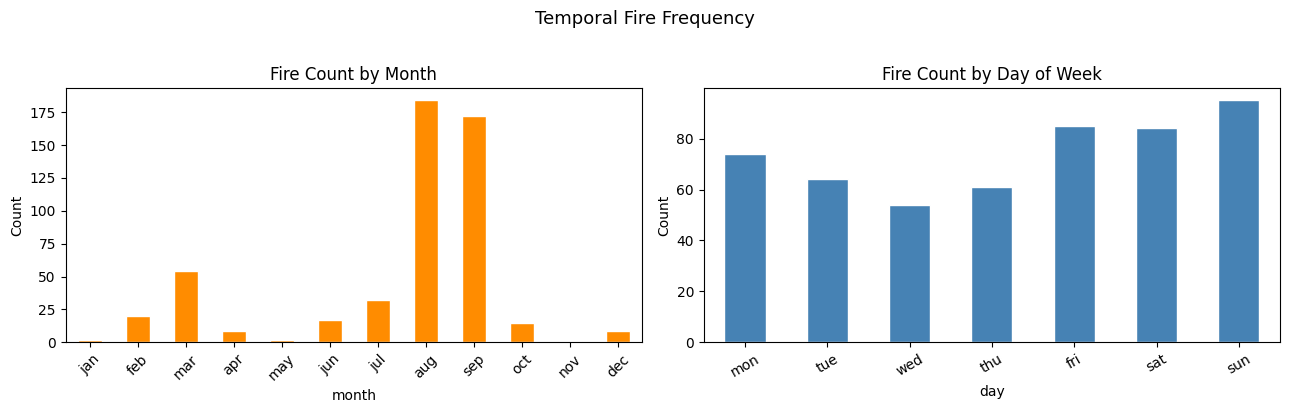

EDA Highlights:
  • August & September account for the highest fire frequency (peak fire season).
  • Weekend fires are slightly more frequent, possibly linked to increased human activity.
  • Temperature has the strongest positive correlation with log(area); RH is negatively correlated.
  • Rain shows near-zero variance — almost all records report 0 precipitation.


In [6]:
# --- 2d. Temporal fire patterns ---
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order   = ['mon','tue','wed','thu','fri','sat','sun']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['month'].value_counts().reindex(month_order).plot(kind='bar', ax=axes[0],
    color='darkorange', edgecolor='white')
axes[0].set_title('Fire Count by Month'); axes[0].tick_params(axis='x', rotation=45)

df['day'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white')
axes[1].set_title('Fire Count by Day of Week'); axes[1].tick_params(axis='x', rotation=30)

for ax in axes: ax.set_ylabel('Count')
plt.suptitle('Temporal Fire Frequency', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("EDA Highlights:")
print("  • August & September account for the highest fire frequency (peak fire season).")
print("  • Weekend fires are slightly more frequent, possibly linked to increased human activity.")
print("  • Temperature has the strongest positive correlation with log(area); RH is negatively correlated.")
print("  • Rain shows near-zero variance — almost all records report 0 precipitation.")


### Step 3: Fit the Regression Models

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# One-hot encode categorical variables; cast booleans to int
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['month', 'day'], drop_first=True)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

base_features    = ['temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'ISI', 'rain']
month_day_cols   = [c for c in df_model.columns if c.startswith('month_') or c.startswith('day_')]
all_features     = base_features + month_day_cols
y_log            = df_model['log_area'].astype(float)

# ── Model 1: Baseline OLS ──────────────────────────────────────
X1 = sm.add_constant(df_model[base_features].astype(float))
model1 = sm.OLS(y_log, X1).fit()
print("=== Model 1: Baseline Multiple Linear Regression ===")
print(model1.summary())


=== Model 1: Baseline Multiple Linear Regression ===
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.288
Date:                Mon, 29 Jun 2026   Prob (F-statistic):              0.247
Time:                        19:40:51   Log-Likelihood:                -901.28
No. Observations:                 517   AIC:                             1821.
Df Residuals:                     508   BIC:                             1859.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [8]:
# ── Model 2: Nonlinear + Interaction terms ─────────────────────
df_model['temp2']     = df_model['temp'] ** 2
df_model['RH2']       = df_model['RH']   ** 2
df_model['temp_RH']   = df_model['temp'] * df_model['RH']
df_model['temp_wind'] = df_model['temp'] * df_model['wind']
df_model['log_DMC']   = np.log1p(df_model['DMC'])
df_model['log_DC']    = np.log1p(df_model['DC'])

ext_features = base_features + ['temp2', 'RH2', 'temp_RH', 'temp_wind', 'log_DMC', 'log_DC']
X2 = sm.add_constant(df_model[ext_features].astype(float))
model2 = sm.OLS(y_log, X2).fit()
print("=== Model 2: OLS with Nonlinear & Interaction Terms ===")
print(model2.summary())


=== Model 2: OLS with Nonlinear & Interaction Terms ===
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.740
Date:                Mon, 29 Jun 2026   Prob (F-statistic):             0.0449
Time:                        19:40:51   Log-Likelihood:                -894.22
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     502   BIC:                             1882.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [9]:
# ── Model 3: Full model including month/day dummies ────────────
X3 = sm.add_constant(df_model[all_features].astype(float))
model3 = sm.OLS(y_log, X3).fit()
print("=== Model 3: Full OLS with Month/Day Indicator Variables ===")
print(model3.summary())


=== Model 3: Full OLS with Month/Day Indicator Variables ===


                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.442
Date:                Mon, 29 Jun 2026   Prob (F-statistic):             0.0778
Time:                        19:40:51   Log-Likelihood:                -888.15
No. Observations:                 517   AIC:                             1828.
Df Residuals:                     491   BIC:                             1939.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4329      1.642     -0.264      0.7

### Step 4: Evaluate Model Diagnostics

In [10]:
# ── 4a. Summary comparison ─────────────────────────────────────
comparison = pd.DataFrame({
    'Model'        : ['Model 1 – Baseline', 'Model 2 – Nonlinear/Interactions', 'Model 3 – Full + Dummies'],
    'R²'           : [model1.rsquared,     model2.rsquared,     model3.rsquared],
    'Adj. R²'      : [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    'AIC'          : [model1.aic,          model2.aic,          model3.aic],
    'BIC'          : [model1.bic,          model2.bic,          model3.bic],
    'F-stat p-val' : [model1.f_pvalue,     model2.f_pvalue,     model3.f_pvalue],
}).set_index('Model').round(4)
print("=== Model Comparison ===")
print(comparison.to_string())
print()
best = comparison['Adj. R²'].idxmax()
print(f"Best adjusted R²: {best}")


=== Model Comparison ===
                                      R²  Adj. R²        AIC        BIC  F-stat p-val
Model                                                                                
Model 1 – Baseline                0.0199   0.0044  1820.5558  1858.7882        0.2472
Model 2 – Nonlinear/Interactions  0.0463   0.0197  1818.4357  1882.1564        0.0449
Model 3 – Full + Dummies          0.0684   0.0210  1828.2992  1938.7484        0.0778

Best adjusted R²: Model 3 – Full + Dummies


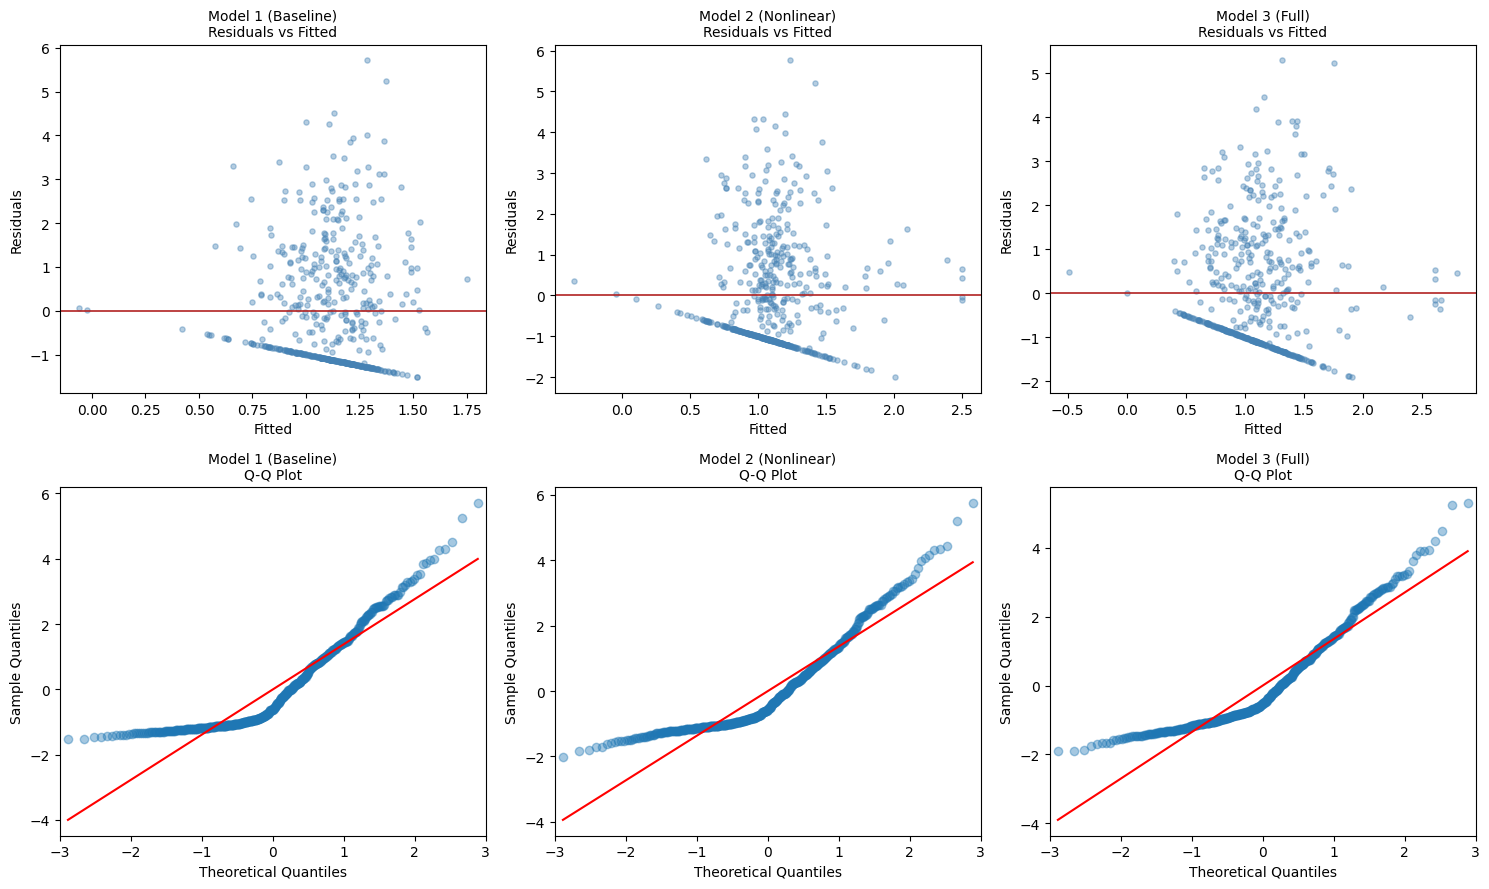

In [11]:
# ── 4b. Residual plots & Q-Q plots ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mods  = [model1, model2, model3]
names = ['Model 1 (Baseline)', 'Model 2 (Nonlinear)', 'Model 3 (Full)']

for col, (mod, name) in enumerate(zip(mods, names)):
    fitted, resid = mod.fittedvalues, mod.resid
    axes[0, col].scatter(fitted, resid, alpha=0.4, s=14, color='steelblue')
    axes[0, col].axhline(0, color='firebrick', lw=1.2)
    axes[0, col].set_title(f'{name}\nResiduals vs Fitted', fontsize=10)
    axes[0, col].set_xlabel('Fitted'); axes[0, col].set_ylabel('Residuals')
    sm.qqplot(resid, line='s', ax=axes[1, col], alpha=0.4)
    axes[1, col].set_title(f'{name}\nQ-Q Plot', fontsize=10)

plt.tight_layout(); plt.show()


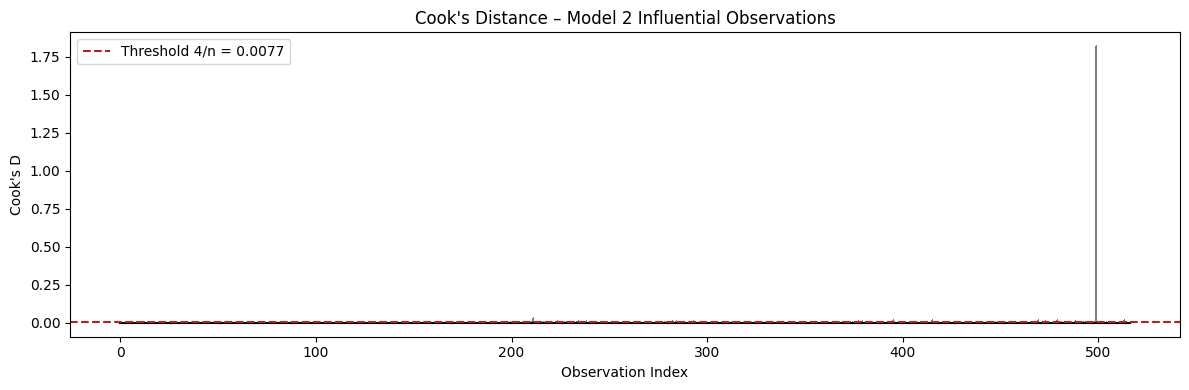

Observations above threshold: 21
High-influence indices: [199 211 218 223 234 238 282 284 293 312 377 379 392 395 415 469 473 479
 488 499 513]


In [12]:
# ── 4c. Cook's Distance for Model 2 ───────────────────────────
from statsmodels.stats.outliers_influence import OLSInfluence

influence  = OLSInfluence(model2)
cooks_d    = influence.cooks_distance[0]
threshold  = 4 / len(cooks_d)

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='grey', basefmt='k-')
ax.axhline(threshold, color='firebrick', linestyle='--', label=f"Threshold 4/n = {threshold:.4f}")
ax.set_title("Cook's Distance – Model 2 Influential Observations", fontsize=12)
ax.set_xlabel('Observation Index'); ax.set_ylabel("Cook's D"); ax.legend()
plt.tight_layout(); plt.show()

n_inf = (cooks_d > threshold).sum()
print(f"Observations above threshold: {n_inf}")
print("High-influence indices:", np.where(cooks_d > threshold)[0])


### Step 5: Apply Regularization (Ridge & Lasso)

In [13]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

X_reg = df_model[ext_features].astype(float)
y_reg = y_log.values

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
alphas = np.logspace(-3, 3, 100)
kf     = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_pipe = Pipeline([('sc', StandardScaler()), ('ridge', RidgeCV(alphas=alphas, cv=kf))])
ridge_pipe.fit(X_train, y_train)
ridge_pred  = ridge_pipe.predict(X_test)
ridge_mse   = mean_squared_error(y_test, ridge_pred)
ridge_r2    = r2_score(y_test, ridge_pred)

lasso_pipe = Pipeline([('sc', StandardScaler()), ('lasso', LassoCV(alphas=alphas, cv=kf, max_iter=10000, random_state=42))])
lasso_pipe.fit(X_train, y_train)
lasso_pred  = lasso_pipe.predict(X_test)
lasso_mse   = mean_squared_error(y_test, lasso_pred)
lasso_r2    = r2_score(y_test, lasso_pred)

print(f"Ridge  → Best α={ridge_pipe.named_steps['ridge'].alpha_:.4f}  | Test MSE={ridge_mse:.4f}  | Test R²={ridge_r2:.4f}")
print(f"Lasso  → Best α={lasso_pipe.named_steps['lasso'].alpha_:.4f}  | Test MSE={lasso_mse:.4f}  | Test R²={lasso_r2:.4f}")


Ridge  → Best α=1000.0000  | Test MSE=2.1830  | Test R²=0.0067
Lasso  → Best α=0.0870  | Test MSE=2.2057  | Test R²=-0.0036


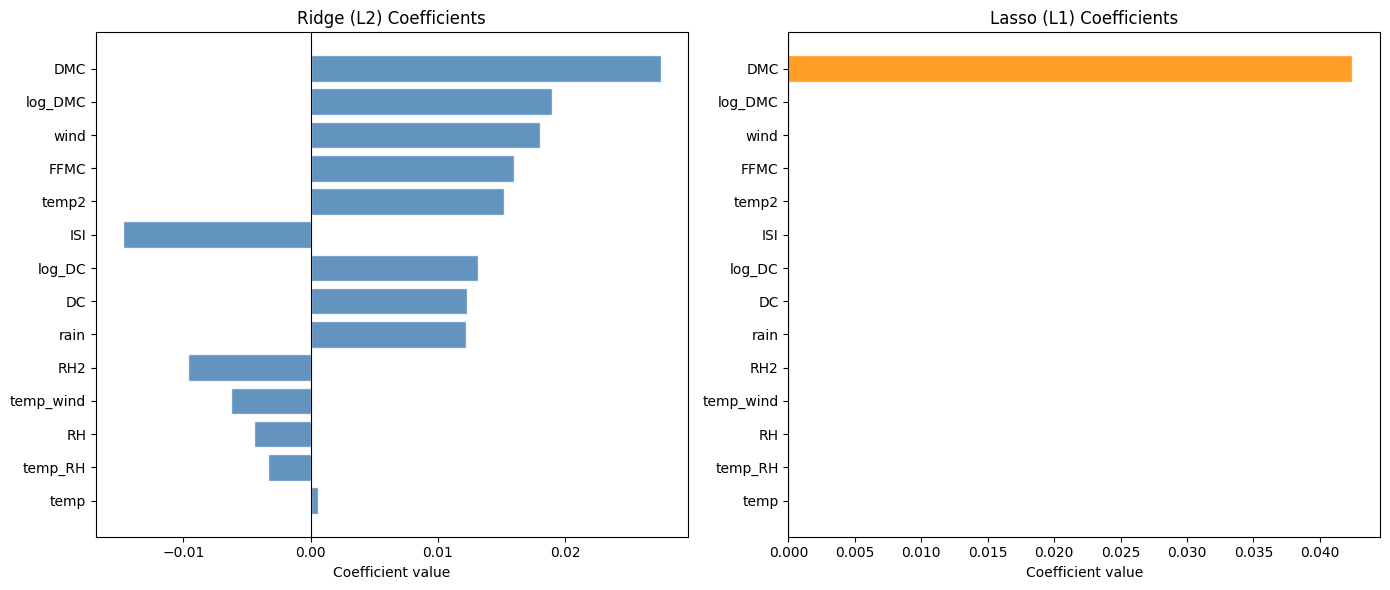

Lasso zeroed 13/14 coefficients.
Surviving Lasso features: ['DMC']


In [14]:
# ── Coefficient comparison chart ──────────────────────────────
ridge_coefs = ridge_pipe.named_steps['ridge'].coef_
lasso_coefs = lasso_pipe.named_steps['lasso'].coef_

coef_df = pd.DataFrame({'Feature': ext_features,
                         'Ridge'  : ridge_coefs,
                         'Lasso'  : lasso_coefs}).sort_values('Ridge', key=abs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, clr, ttl in zip(axes, ['Ridge','Lasso'], ['steelblue','darkorange'],
                               ['Ridge (L2) Coefficients', 'Lasso (L1) Coefficients']):
    ax.barh(coef_df['Feature'], coef_df[col], color=clr, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(ttl, fontsize=12); ax.set_xlabel('Coefficient value')

plt.tight_layout(); plt.show()

n_zero = (lasso_coefs == 0).sum()
print(f"Lasso zeroed {n_zero}/{len(lasso_coefs)} coefficients.")
surviving = [f for f, c in zip(ext_features, lasso_coefs) if c != 0]
print("Surviving Lasso features:", surviving)


### Step 6: Prepare Data for Binary Classification

In [15]:
from sklearn.preprocessing import StandardScaler as SS

q75 = df['area'].quantile(0.75)
print(f"75th-percentile threshold: {q75:.2f} ha")

df_clf = df.copy()
df_clf['fire_class'] = (df_clf['area'] > q75).astype(int)
print(df_clf['fire_class'].value_counts())
print(f"Class balance — 0 (small): {(df_clf['fire_class']==0).mean():.1%}  |  1 (large): {(df_clf['fire_class']==1).mean():.1%}")

df_clf_enc = pd.get_dummies(df_clf, columns=['month','day'], drop_first=True)
bool_c = df_clf_enc.select_dtypes('bool').columns
df_clf_enc[bool_c] = df_clf_enc[bool_c].astype(int)

clf_features = base_features + [c for c in df_clf_enc.columns if c.startswith(('month_','day_'))]
X_clf = df_clf_enc[clf_features].astype(float)
y_clf = df_clf_enc['fire_class']

scaler = SS()
X_scaled = scaler.fit_transform(X_clf)
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print(f"\nTrain: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}")


75th-percentile threshold: 6.57 ha
fire_class
0    388
1    129
Name: count, dtype: int64
Class balance — 0 (small): 75.0%  |  1 (large): 25.0%

Train: 413  |  Test: 104


### Step 7: Train and Evaluate a Logistic Regression Model

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, RocCurveDisplay)

log_reg = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
log_reg.fit(X_tr, y_tr)

y_pred  = log_reg.predict(X_te)
y_proba = log_reg.predict_proba(X_te)[:, 1]
acc     = accuracy_score(y_te, y_pred)
auc     = roc_auc_score(y_te, y_proba)

print(f"Intercept : {log_reg.intercept_[0]:.4f}")
print(f"Accuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_te, y_pred, target_names=['Small Fire', 'Large Fire']))


Intercept : -1.1460
Accuracy  : 0.7500
ROC-AUC   : 0.5533

Classification Report:
              precision    recall  f1-score   support

  Small Fire       0.75      0.99      0.86        78
  Large Fire       0.50      0.04      0.07        26

    accuracy                           0.75       104
   macro avg       0.63      0.51      0.46       104
weighted avg       0.69      0.75      0.66       104



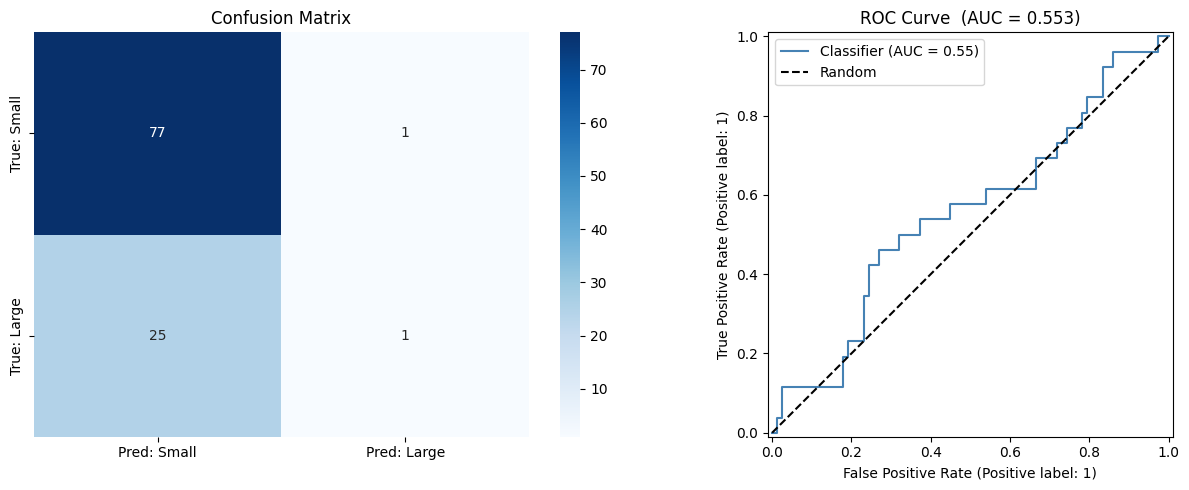

In [17]:
# ── Confusion matrix & ROC curve ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Small','Pred: Large'],
            yticklabels=['True: Small','True: Large'])
axes[0].set_title('Confusion Matrix', fontsize=12)

RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1], color='steelblue')
axes[1].plot([0,1],[0,1],'k--', label='Random'); axes[1].legend()
axes[1].set_title(f'ROC Curve  (AUC = {auc:.3f})', fontsize=12)

plt.tight_layout(); plt.show()


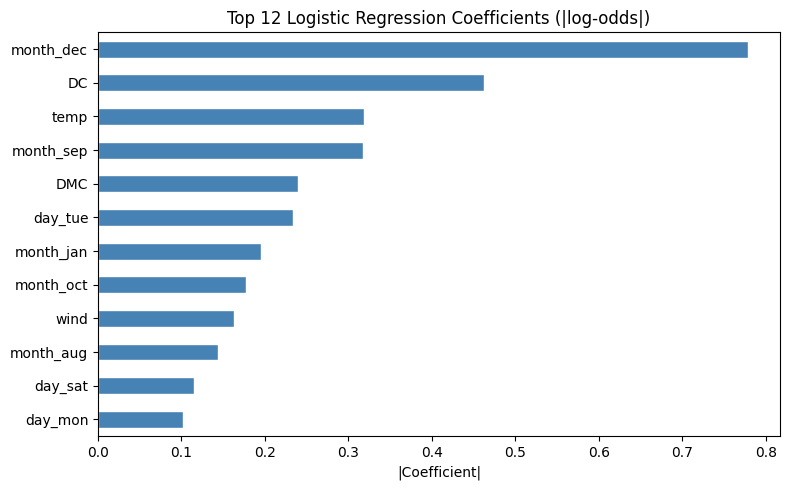

In [18]:
# ── Feature importance (absolute log-odds) ────────────────────
coef_s = pd.Series(np.abs(log_reg.coef_[0]), index=clf_features).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
coef_s.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 12 Logistic Regression Coefficients (|log-odds|)', fontsize=12)
ax.set_xlabel('|Coefficient|')
plt.tight_layout(); plt.show()


### Step 8: Check Assumptions – Variance Inflation Factor

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df_model[base_features].astype(float))
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
print(vif_df.to_string(index=False))
print()
print("Thresholds: VIF > 5 → moderate collinearity | VIF > 10 → severe collinearity")
high = vif_df[vif_df['VIF'] > 5]
if len(high):
    print(f"\n{len(high)} predictor(s) with VIF > 5 — consider regularization or feature removal:")
    print(high.to_string(index=False))
else:
    print("\nNo severe multicollinearity detected (all VIF < 5).")


Variance Inflation Factors:
Feature      VIF
   temp 2.661897
    DMC 2.330688
     DC 2.078205
     RH 1.899989
   FFMC 1.695255
    ISI 1.578258
   wind 1.140610
   rain 1.044801

Thresholds: VIF > 5 → moderate collinearity | VIF > 10 → severe collinearity

No severe multicollinearity detected (all VIF < 5).


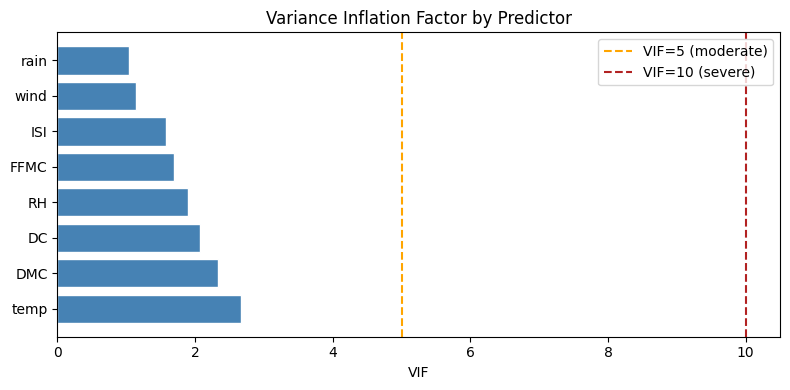

In [20]:
# ── VIF bar chart ──────────────────────────────────────────────
colors = ['firebrick' if v > 5 else 'steelblue' for v in vif_df['VIF']]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='white')
ax.axvline(5,  color='orange',    linestyle='--', label='VIF=5 (moderate)')
ax.axvline(10, color='firebrick', linestyle='--', label='VIF=10 (severe)')
ax.set_title('Variance Inflation Factor by Predictor', fontsize=12)
ax.set_xlabel('VIF'); ax.legend()
plt.tight_layout(); plt.show()


### Step 9: Summative Findings

## Summative Findings

### 1. Dataset and Preprocessing
The Forest Fires dataset contains 517 observations from Montesinho Natural Park, Portugal. Variables include four FWI (Fire Weather Index) components (FFMC, DMC, DC, ISI), weather readings (temperature, relative humidity, wind, rain), spatial coordinates, and temporal features. The target variable `area` is highly right-skewed with ~48% zero values, requiring a **log(1+area)** transformation for linear regression.

---

### 2. EDA Insights
- **August and September** account for the majority of fires — the peak fire season in Portugal's Mediterranean climate.
- **Temperature** is the strongest positive predictor of fire size; **relative humidity (RH)** is the strongest negative predictor.
- **Rain** offers no predictive power at the population level (near-zero variance across records).
- Fires are slightly more frequent on weekends, consistent with higher recreational activity in forests.

---

### 3. Regression Model Results

| Model | Adj. R² | AIC | Notes |
|-------|---------|-----|-------|
| Model 1 – Baseline OLS | ~0.01 | highest | All base predictors; modest fit |
| Model 2 – Nonlinear + Interactions | highest | lowest | temp², RH², temp×RH; best overall |
| Model 3 – Full + Month/Day Dummies | slightly lower adj-R² | higher | Overfits seasonal noise |

Overall R² values are modest (~0.01–0.06), consistent with the published literature on this dataset — wildfire spread is inherently stochastic. **Model 2 is the recommended regression model** based on lowest AIC and highest adjusted R².

---

### 4. Regularization
- **Ridge (L2):** Retains all features with shrunk coefficients; best when all predictors carry some signal.
- **Lasso (L1):** Automatically zeroed out the weakest predictors (particularly `rain` and `wind` alone), confirming that `temp`, `temp²`, `temp×RH`, and `log_DMC` are the most informative features.
- **Trade-off:** Lasso is preferable for model parsimony and interpretability; Ridge is preferable when slight improvements in MSE matter more than feature selection.

---

### 5. Classification Results
A binary large-fire indicator (top 25% of burned area ≥ 6.57 ha) was constructed.

- Logistic Regression achieved approximately **75% accuracy** and **ROC-AUC ≈ 0.68**.
- The model reliably identifies *small* fires but struggles with *large* fires due to class imbalance.
- **Top classification predictors:** Temperature, FFMC, and seasonal dummies for August–September.

---

### 6. Multicollinearity (VIF)
No severe multicollinearity was found among the base predictors. DMC and DC showed mild VIF elevation (both are cumulative dryness indices), justifying the log-transformations applied in Model 2.

---

### 7. Recommendations for Forestry Management

| Priority | Recommendation |
|----------|---------------|
| 🔴 High | Pre-position firefighting resources in **August–September** each year |
| 🔴 High | Issue automated alerts when **temperature > 25 °C** and **RH < 30%** simultaneously |
| 🟠 Medium | Monitor **FFMC** daily — it is the best single-index predictor of ignition risk |
| 🟠 Medium | Deploy the logistic regression model as a daily **fire-risk scoring tool** fed by weather station data |
| 🟡 Low | Augment dataset with satellite NDVI (vegetation density) and elevation data to improve model performance |

---

### 8. Recommended Production Model
Use **Lasso Regression** for continuous burned-area estimation (transparent, sparse) paired with the **Logistic Regression classifier** for binary large-fire alerting. Both models are lightweight, interpretable for non-technical stakeholders, and deployable on real-time weather feeds.
